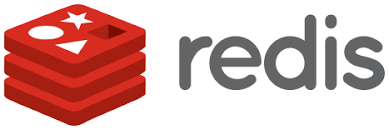

# Boostez vos applications avec Redis !

Imaginez une application qui doit gérer des sessions utilisateur, des compteurs, des files de tâches, des classements ou encore des données temporaires consultées des millions de fois.

Interroger systématiquement une base de données traditionnelle n’est pas toujours la solution la plus efficace. Redis permet de conserver et de manipuler des données directement en mémoire, avec des structures adaptées aux besoins de l’application.

Mais Redis ne se résume pas à stocker une simple paire clé → valeur !

STRING, HASH, LIST, SET, ZSET… chaque structure répond à des besoins différents. Toute la difficulté consiste donc à choisir la bonne structure pour le bon usage.

Dans ce TP, vous allez manipuler Redis avec redis-cli, découvrir ses principales structures de données, puis les exploiter depuis Python avec redis-py.

:::{important} Objectifs pédagogiques

À l’issue de ce TP, vous serez capables de :

* manipuler des données dans Redis avec redis-cli ;
* utiliser les principales structures : STRING, HASH, LIST, SET et ZSET ;
* choisir une structure Redis en fonction d’un cas d’utilisation ;
* gérer des données temporaires grâce aux mécanismes d’expiration (TTL) ;
* interagir avec Redis depuis une application Python avec redis-py.

:::



## Prérequis

* Vérifier que Docker Desktop est bien démarré
* Ouvrir un terminal
* À partir du terminal, se positionner dans le répertoire `anf_rbdd_nosql_092026/docker`.
  

Démarrer votre container redis :

Vérifiez que votre container redis est opérationnel :

Pour accéder au contenu du container, ouvrez un terminal (Powershell pour les windows) et lancez la commande suivante :


Vous pouvez vous connecter à Redis en utilisant le client embarqué avec Redis :

Vous devriez obtenir l'affichage suivant : 

Tapez la commande ping :

Le résultat PONG devrait vous être retourné. Il confirme que votre client communique correctement avec le serveur Redis.

Vous êtes maintenant prêt à commencer ce TP !

Avant de manipuler Redis, il est essentiel de comprendre les structures de données qu’il met à votre disposition. En effet, avec Redis, le choix d’une structure dépend directement de la manière dont les données seront utilisées par l’application.

La section suivante vous guidera dans la découverte et la manipulation des principales structures de données proposées par Redis.

## Les structures REDIS

Redis continue d’évoluer et propose aujourd’hui des fonctionnalités permettant de manipuler des données plus complexes, notamment des documents JSON ou des vecteurs, utilisés par exemple pour la recherche sémantique et les applications d’IA.

Dans ce TP d’introduction, nous nous concentrerons sur les structures et mécanismes fondamentaux de Redis : STRING • LIST • SET • ZSET • PUB/SUB

L'ensemble des types sont disponibles ici :
https://redis.io/docs/latest/develop/data-types/streams/

Ces mécanismes permettent déjà de répondre à de nombreux cas d’utilisation que nous allons maintenant découvrir et mettre en pratique.

### STRING

À partir du terminal ouvert précédemment, vous allez maintenant exécuter quelques commandes simples afin de vous familiariser avec Redis.

Commençons par la structure la plus simple : STRING.

Pour enregistrer une paire clé/valeur, Redis utilise la commande **SET** :

```
set mykey myvalue
```

Si l’opération s’est correctement déroulée, Redis vous retourne : OK

On peut ensuite récupérer la valeur associée à cette clé avec la commande GET :
```
get mykey
```

La commande MSET (Multi SET) permet d’enregistrer plusieurs paires clé/valeur en une seule opération.

Par exemple :

```
mset mykey1 1 mykey2 test2
```

Redis enregistre alors plusieurs paires :
```
mykey1 -> 1
mykey  -> 2
```
Pour collecter la valeur d'une clé, utilisez la fonction GET :

Pour supprimer une ou plusieurs paires clé/valeur, utilisez la commande DEL :

Par exemple :

Redis nous confirme la suppression avec le retour 1. 
Si la clé n’existe pas, Redis ignore simplement la suppression et ne la comptabilise pas dans le nombre de clés supprimées.

Si la valeur associée à une clé est un nombre entier, vous pouvez utiliser les commandes INCR et DECR pour respectivement l’incrémenter ou la décrémenter.

Bien entendu, si la valeur n'est pas convertible en entier alors REDIS retournera une erreur :

Vous pouvez obtenir de l'aide sur les commandes avec l'instruction help

### SET / Tableau

Une clé Redis peut également être associée à un SET.

Un SET est une collection de valeurs uniques et non ordonnées. Contrairement à une LIST, il est donc impossible d’y stocker plusieurs fois la même valeur.

Les principales commandes permettant de manipuler un SET sont :

* SADD : ajoute un ou plusieurs membres au SET ;
* SMEMBERS : retourne l’ensemble des membres du SET ;
* SISMEMBER : vérifie si une valeur appartient au SET ;
* SREM : supprime un ou plusieurs membres du SET.

Par exemple créons un SET nommé myset et ajoutons plusieurs valeurs :

Chaque commande retourne 1, indiquant qu’un nouveau membre a bien été ajouté au SET.
Essayons maintenant d’ajouter une seconde fois setval1 :

Redis retourne cette fois 0 : aucun nouveau membre n’a été ajouté, car setval1 existe déjà.

Pour afficher l’ensemble des membres du SET, utilisez SMEMBERS :

Remarquez que les valeurs ne sont pas nécessairement retournées dans leur ordre d’insertion : un SET est une collection non ordonnée.

La commande SISMEMBER permet de vérifier si une valeur appartient au SET :

La valeur 1 indique que setval3 est bien présente dans myset. Une valeur absente aurait retourné 0.

Pour supprimer un membre, utilisez SREM :

Redis retourne 1, car le membre existait et a bien été supprimé. Vérifions le contenu :

127.0.0.1:6379> SMEMBERS myset
1) "setval1"
2) "setval2"

:::{tip} À retenir : 
un SET permet de stocker des valeurs uniques, de vérifier rapidement leur appartenance avec SISMEMBER et de les ajouter ou supprimer avec SADD et SREM.
:::

### LIST / Liste

Dans Redis, une clé peut être associée à une liste ordonnée de chaînes de caractères. Contrairement aux SET, une LIST peut contenir plusieurs fois la même valeur.

Redis permet d’ajouter ou de retirer des éléments aux deux extrémités de la liste :

* RPUSH : ajoute une ou plusieurs valeurs à droite de la liste ;
* LPUSH : ajoute une ou plusieurs valeurs à gauche de la liste ;
* LRANGE : retourne les valeurs comprises dans un intervalle d’indices ;
* LINDEX : retourne la valeur située à une position donnée ;
* LPOP : retire et retourne la valeur située à gauche ;
* RPOP : retire et retourne la valeur située à droite.

Créons une liste mylist et ajoutons un premier élément à droite avec RPUSH :

Redis retourne la nouvelle taille de la liste. Notre liste contient donc un élément.

Ajoutons maintenant deux valeurs supplémentaires :

Puis ajoutons une nouvelle fois value1 :

Contrairement à un SET, une LIST autorise les doublons. Vérifions son contenu :

L’indice 0 correspond au premier élément et -1 au dernier élément de la liste.

La commande LPOP permet de retirer et retourner l’élément situé à gauche de la liste :

La liste contient désormais :

:::{hint} À retenir : 
une LIST Redis est ordonnée et autorise les doublons. RPUSH ajoute des éléments à droite, tandis que LPOP retire un élément à gauche. Cette combinaison permet notamment d’implémenter une file FIFO (First In, First Out).
:::

Pour consulter les clés correspondant à un motif, vous pouvez utiliser `KEYS` :

### HASH / dictionnaire

Les structures LIST et SET permettent de stocker une collection de valeurs. Redis permet également de regrouper, sous une même clé, plusieurs paires champ/valeur grâce à la structure HASH.

Un HASH est particulièrement adapté pour représenter un objet possédant plusieurs propriétés, comme un utilisateur, un produit ou une configuration.

Par exemple, un utilisateur peut être représenté ainsi :


Les principales commandes permettant de manipuler un HASH sont :

* HSET : ajoute ou modifie un ou plusieurs champs et leurs valeurs ;
* HGET : retourne la valeur associée à un champ ;
* HGETALL : retourne l’ensemble des champs et valeurs du HASH ;
* HDEL : supprime un ou plusieurs champs ;
* HEXISTS : vérifie si un champ existe dans le HASH.

Exemple

Créons un HASH représentant un utilisateur :

Ajoutons plusieurs informations :

Notre clé user:100 contient maintenant :

Pour récupérer uniquement le nom :

Pour récupérer l’ensemble des informations :

Il est également possible de modifier directement un champ existant :

Redis retourne ici 0 car aucun nouveau champ n’a été créé : le champ city existait déjà et sa valeur a simplement été modifiée.

:::{hint} À retenir :
un HASH permet de regrouper plusieurs champs/valeurs sous une même clé Redis. Il est particulièrement adapté pour représenter simplement les différentes propriétés d’un objet.
:::

### ZSET

Un ZSET (Sorted Set) est un ensemble de valeurs uniques et ordonnées selon un score numérique.

Chaque élément est donc constitué de deux informations :

Par exemple, pour représenter le classement de joueurs :

Les principales commandes permettant de manipuler un ZSET sont :

* ZADD : ajoute un membre et lui associe un score ;
* ZRANGE : retourne les membres selon leur position dans le classement ;
* ZRANGEBYSCORE : retourne les membres dont le score appartient à un intervalle ;
* ZREM : supprime un membre du ZSET.

Exemple

Créons un classement de joueurs :

Le ZSET contient maintenant :

:::{warning} Attention : 
Si le membre existe déjà dans le ZSET, la commande ZADD met à jour son score au lieu de créer un nouveau membre.
:::

Dans ce cas, ZADD retourne 0, car aucun nouveau membre n’a été ajouté. Par défaut, la valeur retournée par ZADD correspond au nombre de nouveaux membres ajoutés, et non au nombre de scores modifiés.

Par défaut, ZRANGE retourne les membres du score le plus faible au score le plus élevé :

Pour obtenir un véritable classement du meilleur score au plus faible, vous pouvez utiliser :

Il est également possible de rechercher les joueurs selon leur score :

Enfin, pour supprimer un joueur :

:::{tip}À retenir : 
contrairement à un SET, un ZSET associe un score à chaque membre et utilise ce score pour maintenir automatiquement un ordre. Cette structure est particulièrement adaptée aux classements, scores, priorités ou données ordonnées.
:::

Vous êtes à présent familiarisés avec les principales structures de données de Redis et les commandes permettant de les manipuler.

Comme vous avez pu le constater, les commandes Redis restent relativement simples et permettent principalement de créer, lire, modifier et supprimer des données.

Cependant, dès que nous souhaitons mettre en œuvre une logique applicative plus complexe — enchaîner plusieurs opérations, effectuer des traitements, prendre des décisions ou répéter des actions — nous pouvons utiliser un langage de programmation comme Python, Java, JavaScript, etc., et communiquer avec Redis à l’aide d’une bibliothèque cliente.

Dans la suite de ce TP, nous allons utiliser Python avec la bibliothèque redis-py pour interagir avec notre serveur Redis.

:::{note} Pas d’inquiétude !
si vous ne connaissez pas Python !
Nous resterons sur des instructions très simples. L’objectif n’est pas d’apprendre Python, mais de comprendre comment une application peut utiliser Redis pour stocker et manipuler ses données.
:::

## Utiliser Redis avec Python

Pour vous familiariser avec l’API proposée par la bibliothèque redis-py, vous pouvez consulter la  ⁠[documentation officielle de redis-py]( https://redis.io/docs/latest/commands/).

Vous constaterez que les méthodes Python sont très proches des commandes que vous venez d’utiliser avec redis-cli. 

Par exemple :

```
r : objet de connexion à Redis

Redis            Python avec redis-py
------           --------------------
SET              r.set()
GET              r.get()
HSET             r.hset()
SADD             r.sadd()
RPUSH            r.rpush()
ZADD             r.zadd()
```



Les commandes Python sont très similaires aux commandes du client Redis.

Si vous exécutez ce notebook dans JupyterLab, conservez la configuration `host='redis', port=6379` indiquée dans la cellule de connexion.

### Connexion à la base de données

La suite du TP peut être réalisée directement depuis le notebook JupyterLab.

Le notebook est composé de cellules contenant du texte ou du code Python. Pour exécuter une cellule de code :

1. sélectionnez la cellule en cliquant dessus ;
2. cliquez sur le bouton ▶ Exécuter dans la barre d’outils.

Vous pouvez également utiliser le raccourci clavier Shift + Entrée pour exécuter la cellule sélectionnée et passer automatiquement à la suivante.

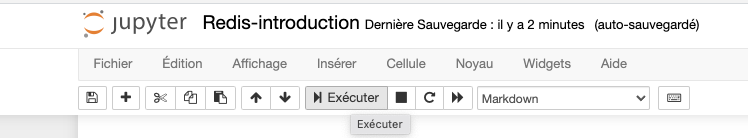

In [11]:
# Import du module redis-py après son installation via 'pip install redis'
import redis
print('la version de la librairie redis-py utilisée : ', redis.__version__)

la version de la librairie redis-py utilisée :  8.1.0


Lorsque Python s’exécute dans le conteneur JupyterLab, celui-ci communique directement avec le conteneur **redis** à travers le réseau Docker. Utilisez donc :

In [12]:
# Création d'une connexion à Redis.
# decode_responses=True permet de récupérer des chaînes Python plutôt que des octets.
r = redis.Redis(
    host='redis',
    port=6379,
    db=0,
    decode_responses=True
)
print('Super !!! Je suis connecté à mon serveur Redis : ', r.ping())

Super !!! Je suis connecté à mon serveur Redis :  True


La base Redis contient actuellement les clés que vous avez précédemment créées.
Pour consulter les clés correspondant à un motif, on peut utiliser :

https://redis.io/docs/latest/commands/keys/

In [13]:
r.keys('*')

['visites:page:du',
 'cles',
 'user:100',
 'visites:site',
 'tp:online:users',
 'visites:page:accueil',
 'tp:game:leaderboard',
 'clesnum',
 'visites:page:devlog']

### Insertion, recherche et suppression d'éléments String

Les commandes python sont les mêmes que les commandes du client Redis.

Premier exemple clés / valeur (chaîne de caractères) :
https://redis.io/docs/latest/develop/data-types/strings/

In [14]:
r.set("cles", "valeur")

True

Pour récupérer la valeur de la clé "cles" dans la variable res.

In [15]:
res = r.get("cles")
res

'valeur'

Stocker des valeurs numériques

In [16]:
r.set("clesnum",12)

True

In [17]:
r.get("clesnum")

'12'

La méthode get retourne une chaine de caractères, il faut les convertir avant de s'en servir comme des entiers.

In [18]:
a = 10
a= a + int(r.get("clesnum"))


# Conclusion

Vous avez maintenant découvert les principes fondamentaux de Redis et manipulé plusieurs de ses principales structures de données.

La principale idée à retenir est que Redis ne doit pas être considéré uniquement comme un simple stockage clé/valeur. La richesse de Redis vient notamment des structures de données et des opérations associées qu’il met à disposition.

Ainsi, avant de stocker une donnée dans Redis, posez-vous toujours la question :

« Comment mon application va-t-elle utiliser cette donnée ? »

Le choix de la structure Redis découlera souvent directement de la réponse.

Dans les prochains exercices, nous allons mettre ces connaissances en pratique à travers des cas d’utilisation concrets, notamment la gestion de données temporaires avec les TTL, la mise en place d’un cache, les mécanismes Producteur/Consommateur et la communication entre applications avec Pub/Sub.

Vous connaissez maintenant les briques de base de Redis. Il est temps de les assembler pour répondre à de vrais besoins applicatifs.